# 182. Duplicate Emails
https://leetcode.com/problems/duplicate-emails/

## Complexity Comparison

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| GROUP BY + HAVING | O(n) | O(n) | Cleanest approach |
| Self-Join | O(n^2) | O(n) | Join on email, filter id |
| Subquery with COUNT | O(n) | O(n) | Nested query |

## Methodology

This is a SQL problem. Find all duplicate emails in the Person table.
Group by email and use HAVING COUNT(*) > 1 to filter for emails appearing more than once.

## Solutions

### C#

In [ ]:
// SQL Problem - Duplicate Emails
// SQL Solution:
//
// SELECT email AS Email
// FROM Person
// GROUP BY email
// HAVING COUNT(*) > 1;

// C# programmatic equivalent
using System;
using System.Linq;
using System.Collections.Generic;

public class Solution
{
    public static List<string> DuplicateEmails(List<string> emails)
    {
        return emails.GroupBy(e => e)
                     .Where(g => g.Count() > 1)
                     .Select(g => g.Key)
                     .ToList();
    }
}

// Test
var emails = new List<string> { "a@b.com", "c@d.com", "a@b.com" };
Console.WriteLine(string.Join(", ", Solution.DuplicateEmails(emails))); // a@b.com

### Python

In [ ]:
// SQL Problem - Python programmatic equivalent
//
// from collections import Counter
//
// def duplicate_emails(emails):
//     counts = Counter(emails)
//     return [email for email, count in counts.items() if count > 1]

### Go

In [ ]:
// SQL Problem - Go programmatic equivalent
//
// func duplicateEmails(emails []string) []string {
//     counts := make(map[string]int)
//     for _, e := range emails {
//         counts[e]++
//     }
//     var result []string
//     for email, count := range counts {
//         if count > 1 {
//             result = append(result, email)
//         }
//     }
//     return result
// }

### Rust

In [ ]:
// SQL Problem - Rust programmatic equivalent
//
// use std::collections::HashMap;
//
// fn duplicate_emails(emails: &[String]) -> Vec<String> {
//     let mut counts = HashMap::new();
//     for email in emails {
//         *counts.entry(email.clone()).or_insert(0) += 1;
//     }
//     counts.into_iter()
//         .filter(|(_, count)| *count > 1)
//         .map(|(email, _)| email)
//         .collect()
// }

## Example Scenarios

### 1. Common Case — One Duplicate Email

**Input:** Person table: `{(1,'a@b.com'), (2,'c@d.com'), (3,'a@b.com')}`

GROUP BY email produces two groups: `a@b.com` (count=2) and `c@d.com` (count=1). HAVING COUNT(*) > 1 keeps only `a@b.com`.

**WHY it's useful:** Straightforward GROUP BY + HAVING. The aggregation deduplicates automatically. Time: $O(n)$ with hash-based grouping, Space: $O(n)$ for the hash map.

---

### 2. Slightly Complex — Multiple Duplicate Groups

**Input:** `{(1,'a@b.com'), (2,'c@d.com'), (3,'a@b.com'), (4,'c@d.com'), (5,'e@f.com'), (6,'a@b.com')}`

`a@b.com` appears 3 times, `c@d.com` appears 2 times, `e@f.com` appears once. Both `a@b.com` and `c@d.com` pass the HAVING filter. Note `a@b.com` appears only once in the output despite 3 occurrences — GROUP BY ensures deduplication.

**WHY it's tricky:** Multiple groups qualify. The output lists each duplicate email once regardless of how many times it appears in the table.

---

### 3. Edge Case: Time Factor — All Same Email, $n = 10^5$

**Input:** $n = 100{,}000$ rows, all with `email = 'x@y.com'`.

Hash-based grouping inserts 100k rows into one bucket. A self-join approach would produce $n^2 = 10^{10}$ pairs. GROUP BY stays at $O(n)$.

**WHY it tests time:** Worst case for hash collisions — all rows hash to the same group. The aggregation still runs in $O(n)$ because it only increments a counter per row.

---

### 4. Edge Case: Space Factor — All Unique Emails

**Input:** $n = 100{,}000$ rows, each email unique: `user1@test.com` through `user100000@test.com`.

The hash map stores 100k distinct entries (one per unique email). Every group has count=1, so HAVING filters them all out. Result is empty but memory consumption peaks at $O(n)$.

**WHY it tests space:** Maximum number of distinct groups forces the hash map to store $n$ entries. The result is empty but auxiliary space is at its maximum.

---

### 5. Almost-Impossible — Maximum-Length Emails at RFC Limits

**Input:** $n = 50{,}000$ rows. Each email is 254 characters long (RFC 5321 maximum). 25,000 unique emails, each appearing exactly twice.

String hashing costs $O(L)$ per email where $L = 254$. Total hash cost: $O(n \times L) = O(12.7M)$. Hash map memory: $254 \times 25{,}000 \approx 6.35$ MB for keys alone. Result: all 25,000 emails.

**WHY it's extreme:** Long strings inflate both hashing time ($O(L)$ per operation) and memory. True complexity is $O(n \times L)$, not just $O(n)$. A rolling hash or fixed-size fingerprint could amortize the per-character cost.

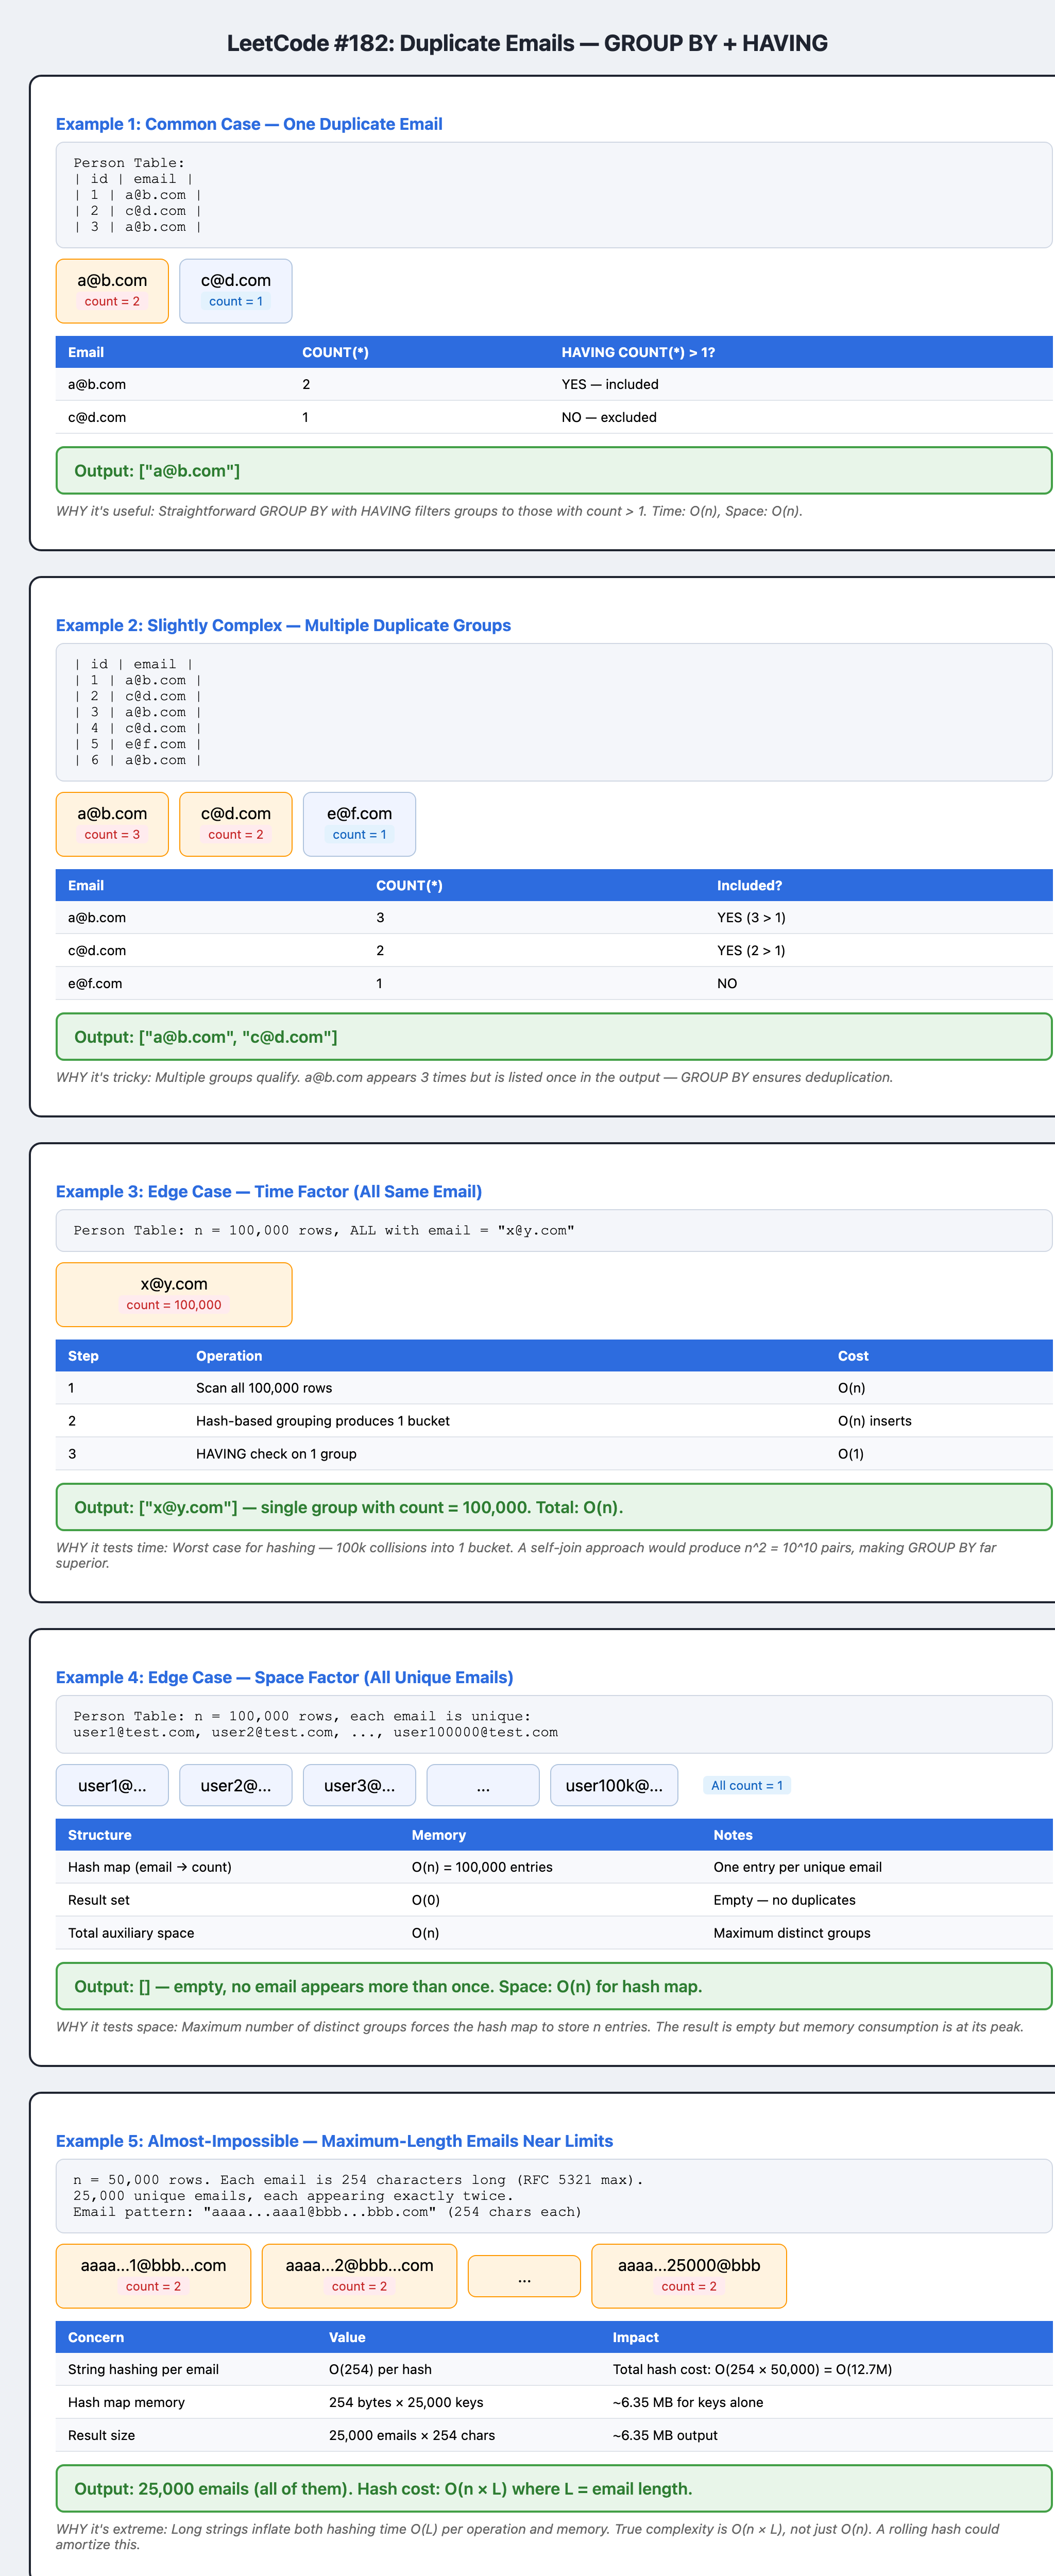